In [1]:
.libPaths("~/R/x86_64-pc-linux-gnu-library/4.4/")

library(Seurat)
library(SeuratDisk)
library(patchwork)
library(harmony)
library(reshape2)
library(RColorBrewer)
library(dplyr)
library(readr)
library(tidyverse)
library(Matrix)
library(Seurat)
library(ggplot2)
library(cowplot)
library(celldex)
library(SingleR)
library(data.table)
library(scGate)
library(ggpubr)
library(scCustomize)
library(GEOquery)

ggtheme <- function() {
  theme(
    axis.text = element_text(size = 20),
    axis.title = element_text(size = 20),
    text = element_text(size = 20, colour = "black"),
    legend.text = element_text(size = 20),
    legend.key.size =  unit(10, units = "points")
    
  )
}


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat

Loading required package: Rcpp


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become erro

In [ ]:
gut_allt_5p <- readRDS("../241201_VN_PREDICT2/data/cdn/gut_allt_5p_integrated.rds")

gut_allt_3p <- readRDS("../241201_VN_PREDICT2/gut_3p_integrated_with_healthy_filt_without_ilc_v2.rds")

In [3]:
ls()

[1] "ggtheme"     "gut_allt_3p" "gut_allt_5p"

# Count of samples - gut

In [233]:
md_5p  <- gut_allt_5p@meta.data

In [234]:
md_3p  <- gut_allt_3p@meta.data

In [235]:
md_5p$version_10x  <- paste0("5p_", md_5p$version_10x)

In [236]:
write.csv(md_5p, "tables/251204_md_gut_allt_5p.csv")
write.csv(md_3p, "tables/251204_md_gut_allt_3p.csv")

In [2]:
md_5p  <- read_csv("tables/251204_md_gut_allt_5p.csv")
md_3p  <- read_csv("tables/251204_md_gut_allt_3p.csv")

New names:
• `` -> `...1`
Rows: 588063 Columns: 133
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (75): ...1, orig.ident, bc, data_folder, data_folder2, sample, diagnosis...
dbl (50): nCount_RNA, nFeature_RNA, age, days, scrublet_doublet_scores, n_ou...
lgl  (8): outliers, is_cell, count_Multi, cdr3_Multi, cdr3_Multi_nt, v_gene_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 283277 Columns: 27
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (14): ...1, SingleR_HPCA, orig.ident, smp_id, patient, time, tissue, lay...
dbl (13): nCount_RNA, nFeature_RNA, RNA_snn_res.0.3, seurat_clusters, percen...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this mess

## Unify disease

In [3]:
md_3p$disease  %>% table

.
      CD     FGID H Pylori      HEA Perineal    Psych       UC 
  126229    93639     7739     9734     8566     8792    28578 

In [4]:
md_3p  %>% group_by(disease, patient)  %>% tally()

disease,patient,n
<chr>,<chr>,<int>
CD,p010,6734
CD,p011,12681
CD,p014,5315
CD,p016,4201
CD,p018,13058
CD,p019,16121
CD,p022,3891
CD,p024,6450
CD,p026,7777


In [5]:
md_3p$disease  <- ifelse(md_3p$patient == "HE-001-014", "OTH", md_3p$disease)

In [6]:
md_3p  %>% group_by(disease, patient)  %>% tally()

disease,patient,n
<chr>,<chr>,<int>
CD,p010,6734
CD,p011,12681
CD,p014,5315
CD,p016,4201
CD,p018,13058
CD,p019,16121
CD,p022,3891
CD,p024,6450
CD,p026,7777


In [7]:
md_5p$diagnosis  %>% table

.
     CD    FGID     HEA     OTH      UC Unknown 
 291704  137903   55923   15156   82404    4973 

In [8]:
md_5p  %>% dplyr::filter(diagnosis == "OTH")  %>% 
group_by(diagnosis, participant_id)  %>% tally()

diagnosis,participant_id,n
<chr>,<chr>,<int>
OTH,001-070,5930
OTH,001-091,873
OTH,003-008,3446
OTH,HE-014,4907


## Unify time

In [9]:
md_3p$time  %>% table

.
    T0    T0D    T3M 
  9734 262575  10968 

In [10]:
md_5p$time  %>% table

Warning message:
“Unknown or uninitialised column: `time`.”


< table of extent 0 >

## Unify layer

In [11]:
md_3p$layer  %>% table

.
   EPI     LP 
 22633 260644 

In [12]:
md_5p$layer  %>% table

.
   EPI     LP 
 73582 514481 

## Unify response

In [13]:
md_3p$antiTNF_response  %>% table

.
    NM    NOA     PR   RESP 
128470  59822  59289  35696 

In [14]:
md_5p$antitnf_response  %>% table

.
     FR      NM     NOA      NR      PR Unknown 
 149454  198990  116162   16296  102188    4973 

## Unify tissue

In [15]:
md_3p$tissue  %>% table

.
   COL    DUO    ILE 
 84608  75236 123433 

In [16]:
md_5p$tissue  %>% table

.
   COL    DUO    ILE 
190539 133081 264443 

## Unify participant ID

In [17]:
md_3p$patient  %>% table

.
HE-001-014 HE-001-023 HE-001-024 HE-001-025 HE-001-026       p002       p003 
      2298       2577       1325        859       2675       3821       6742 
      p009       p010       p011       p014       p015       p016       p017 
      9784       6734      12681       5315      12283       4201       3121 
      p018       p019       p020       p021       p022       p023       p024 
     13058      16121       8566       8792       3891       5355       6450 
      p025       p026       p027       p028       p030       p031       p032 
      7739       7777       9538       6434       7615       6011       7268 
      p033       p034       p035       p036       p037       p038       p040 
      6255       4005       3750       8002       6118       4087       4427 
      p041       p042       p043       p044       p045       p047       p048 
      7048       9608       5818       6194       5469       4206       6101 
      p049       p050 
      6753       6405 

In [18]:
md_5p$participant_id  %>% table

.
001-009 001-011 001-014 001-015 001-016 001-017 001-018 001-019 001-022 001-023 
   6449   19833    6726    7394    4842    7904   10966   13253    7712    6485 
001-024 001-026 001-027 001-028 001-030 001-031 001-032 001-033 001-034 001-035 
   7331    8824    7300    6565    6966    7001    6964    6387    7794    5784 
001-036 001-038 001-040 001-041 001-042 001-043 001-044 001-045 001-047 001-048 
   3267    3272    5455    6427    8846    5468     674    4000    2232   12952 
001-049 001-050 001-051 001-052 001-053 001-055 001-057 001-058 001-059 001-062 
   7859    7096    7971    5798    6745    5225    3638    5280    7235    7788 
001-063 001-064 001-066 001-068 001-069 001-070 001-071 001-074 001-077 001-078 
   5366    9104    2067    2543   14350    5930    3871    4299    5383    2357 
001-079 001-082 001-085 001-086 001-089 001-090 001-091 001-092 001-094 001-101 
   3490    2788    4588    6764    6523    3916     873    3379    3922    4973 
001-103 003-001 003-002 00

In [19]:
md_3p <- md_3p  %>% mutate(diagnosis = ifelse(disease %in% c("CD","FGID","UC","HEA"), disease, "OTH"),
                                             antitnf_response = ifelse(antiTNF_response == "RESP", "FR", antiTNF_response),
                                            participant_id = ifelse(substr(patient,1,1)=="H",patient,
                                                                    paste0("001-",substr(patient,2,4))),
                                            timepoint = ifelse(time %in% c("T0D", "T0"),"T0", "R"),
                                            version_10x = "3p_v1") 

In [20]:
md_3p$participant_id  %>% table

.
   001-002    001-003    001-009    001-010    001-011    001-014    001-015 
      3821       6742       9784       6734      12681       5315      12283 
   001-016    001-017    001-018    001-019    001-020    001-021    001-022 
      4201       3121      13058      16121       8566       8792       3891 
   001-023    001-024    001-025    001-026    001-027    001-028    001-030 
      5355       6450       7739       7777       9538       6434       7615 
   001-031    001-032    001-033    001-034    001-035    001-036    001-037 
      6011       7268       6255       4005       3750       8002       6118 
   001-038    001-040    001-041    001-042    001-043    001-044    001-045 
      4087       4427       7048       9608       5818       6194       5469 
   001-047    001-048    001-049    001-050 HE-001-014 HE-001-023 HE-001-024 
      4206       6101       6753       6405       2298       2577       1325 
HE-001-025 HE-001-026 
       859       2675 

In [21]:
md_3p <- md_3p  %>% mutate(participant_id = gsub(participant_id, pattern = "HE-001-", replacement = "HE-"))

In [22]:
md_3p$participant_id  %>% table

.
001-002 001-003 001-009 001-010 001-011 001-014 001-015 001-016 001-017 001-018 
   3821    6742    9784    6734   12681    5315   12283    4201    3121   13058 
001-019 001-020 001-021 001-022 001-023 001-024 001-025 001-026 001-027 001-028 
  16121    8566    8792    3891    5355    6450    7739    7777    9538    6434 
001-030 001-031 001-032 001-033 001-034 001-035 001-036 001-037 001-038 001-040 
   7615    6011    7268    6255    4005    3750    8002    6118    4087    4427 
001-041 001-042 001-043 001-044 001-045 001-047 001-048 001-049 001-050  HE-014 
   7048    9608    5818    6194    5469    4206    6101    6753    6405    2298 
 HE-023  HE-024  HE-025  HE-026 
   2577    1325     859    2675 

In [23]:
md_3p_to_join  <- md_3p[,colnames(md_3p) %in% colnames(md_5p)]

In [24]:
md_5p_to_join  <- md_5p[,colnames(md_5p) %in% colnames(md_3p_to_join)]

In [25]:
md_3p_to_join  <- md_3p_to_join[,order(colnames(md_3p_to_join))]
md_5p_to_join  <- md_5p_to_join[,order(colnames(md_5p_to_join))]
colnames(md_3p_to_join) == colnames(md_5p_to_join)

[1] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
[16] TRUE TRUE TRUE TRUE

In [26]:
md_3p_to_join$dataset  <- "3p"
md_5p_to_join$dataset  <- "5p"

md  <- rbind(md_3p_to_join, md_5p_to_join)

In [27]:
 md  %>% 
group_by(participant_id, dataset, timepoint, tissue, layer)  %>% tally  

participant_id,dataset,timepoint,tissue,layer,n
<chr>,<chr>,<chr>,<chr>,<chr>,<int>
001-002,3p,T0,COL,EPI,12
001-002,3p,T0,COL,LP,2714
001-002,3p,T0,DUO,EPI,12
001-002,3p,T0,DUO,LP,1083
001-003,3p,T0,COL,EPI,123
001-003,3p,T0,COL,LP,1694
001-003,3p,T0,DUO,EPI,1333
001-003,3p,T0,DUO,LP,3592
001-009,3p,T0,COL,LP,3033


In [28]:
counts_of_patients <- md  %>% 
group_by(participant_id, dataset, timepoint, tissue, layer)  %>% tally  %>% ungroup  %>% 
dplyr::select(-n)  %>% group_by(participant_id, dataset, timepoint, tissue, layer)  %>% tally  %>% 
mutate(timepoint = ifelse(timepoint == "T0","aT0",timepoint))  %>% 
mutate(dataset_time_tissue_layer = paste(dataset, tissue, layer, timepoint))  %>% ungroup  %>% 
dplyr::select(-dataset, -timepoint,  -tissue, -layer)  %>% 
arrange(dataset_time_tissue_layer)  %>% 
pivot_wider(names_from = dataset_time_tissue_layer, values_from = n, values_fill = 0)  %>% 
mutate(yy = 1)

In [29]:
counts_of_patients

participant_id,3p COL EPI aT0,3p COL LP R,3p COL LP aT0,3p DUO EPI R,3p DUO EPI aT0,3p DUO LP R,3p DUO LP aT0,3p ILE EPI R,3p ILE EPI aT0,⋯,5p DUO EPI aT0,5p DUO LP R,5p DUO LP aT0,5p ILE EPI R,5p ILE EPI R2,5p ILE EPI aT0,5p ILE LP R,5p ILE LP R2,5p ILE LP aT0,yy
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>
001-002,1,0,1,0,1,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,1
001-003,1,0,1,0,1,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,1
001-015,1,0,1,0,1,0,1,0,1,⋯,0,0,0,0,0,0,0,0,1,1
001-018,1,0,1,0,1,0,1,0,1,⋯,0,1,1,1,0,0,1,0,1,1
001-024,1,0,1,0,1,0,1,0,1,⋯,0,0,1,0,0,0,0,0,1,1
001-031,1,0,0,0,1,0,1,0,1,⋯,0,0,1,0,0,0,0,0,1,1
001-035,1,0,1,0,1,0,1,0,1,⋯,1,0,1,0,0,0,0,0,1,1
001-036,1,0,1,0,1,0,1,0,1,⋯,0,0,0,0,0,0,0,0,1,1
001-037,1,0,1,0,1,0,1,0,1,⋯,0,0,0,0,0,0,0,0,0,1


In [30]:
participant_list  <- md  %>% group_by(participant_id, diagnosis)  %>% 
tally %>% 
arrange(diagnosis)

In [31]:
participant_list  %>% dplyr::filter(grepl(participant_id, pattern = "HE"))

participant_id,diagnosis,n
<chr>,<chr>,<int>
HE-009,HEA,3485
HE-011,HEA,5010
HE-012,HEA,4753
HE-023,HEA,6432
HE-024,HEA,6149
HE-025,HEA,6032
HE-026,HEA,8976
HE-027,HEA,12618
HE-028,HEA,9904


In [78]:
duplicated(participant_list$participant_id)  %>% table

.
FALSE 
  107 

In [34]:
participant_list$participant_id[which(duplicated(participant_list$participant_id))]

character(0)

In [32]:
patients_5p  <- md_5p$participant_id  %>% unique

In [33]:
patients_5p

[1] "001-009" "001-011" "001-014" "001-015" "001-016" "001-017" "001-018"
  [8] "001-019" "001-022" "001-023" "001-024" "001-026" "001-027" "001-028"
 [15] "001-030" "001-031" "001-032" "001-033" "001-034" "001-035" "001-036"
 [22] "001-038" "001-040" "001-041" "001-042" "001-043" "001-044" "001-045"
 [29] "001-047" "001-048" "001-049" "001-050" "001-051" "001-052" "001-053"
 [36] "001-055" "001-057" "001-058" "001-059" "001-062" "001-063" "001-064"
 [43] "001-066" "001-068" "001-069" "001-070" "001-071" "001-074" "001-077"
 [50] "001-078" "001-079" "001-082" "001-085" "001-086" "001-089" "001-090"
 [57] "001-091" "001-092" "001-094" "001-101" "001-103" "003-001" "003-002"
 [64] "003-004" "003-005" "003-006" "003-007" "003-008" "003-010" "003-011"
 [71] "003-012" "003-016" "003-017" "003-026" "003-027" "003-030" "003-034"
 [78] "003-036" "003-039" "003-042" "003-043" "003-046" "003-051" "003-059"
 [85] "003-066" "003-072" "003-074" "003-077" "HE-009"  "HE-011"  "HE-012" 
 [92] "HE-014"  "HE-023"  "HE-024"  "HE-025"  "HE-026"  "HE-027"  "HE-028" 
 [99] "003-024" "003-021"

In [36]:
patients_3p  <- md_3p$participant_id  %>% unique

In [37]:
patients_3p

[1] "001-002" "001-003" "001-009" "001-010" "001-011" "001-014" "001-015"
 [8] "001-016" "001-017" "001-018" "001-019" "001-020" "001-021" "001-022"
[15] "001-023" "001-024" "001-025" "001-026" "001-027" "001-028" "001-030"
[22] "001-031" "001-032" "001-033" "001-034" "001-035" "001-036" "001-037"
[29] "001-038" "001-040" "001-041" "001-042" "001-043" "001-044" "001-045"
[36] "001-047" "001-048" "001-049" "001-050" "HE-014"  "HE-023"  "HE-024" 
[43] "HE-025"  "HE-026"

In [38]:
patients_5p_only  <- patients_5p[which((patients_5p %in% patients_3p)==F)]

In [40]:
patients_5p_only

[1] "001-051" "001-052" "001-053" "001-055" "001-057" "001-058" "001-059"
 [8] "001-062" "001-063" "001-064" "001-066" "001-068" "001-069" "001-070"
[15] "001-071" "001-074" "001-077" "001-078" "001-079" "001-082" "001-085"
[22] "001-086" "001-089" "001-090" "001-091" "001-092" "001-094" "001-101"
[29] "001-103" "003-001" "003-002" "003-004" "003-005" "003-006" "003-007"
[36] "003-008" "003-010" "003-011" "003-012" "003-016" "003-017" "003-026"
[43] "003-027" "003-030" "003-034" "003-036" "003-039" "003-042" "003-043"
[50] "003-046" "003-051" "003-059" "003-066" "003-072" "003-074" "003-077"
[57] "HE-009"  "HE-011"  "HE-012"  "HE-027"  "HE-028"  "003-024" "003-021"

In [39]:
counts_of_patients2 <- left_join(counts_of_patients, participant_list  %>% 
                                 ungroup  %>% dplyr::select(-n)) %>% 
mutate(diagnosis2 = recode_factor(diagnosis, "CD" = "01_CD", "UC" = "04_UC", "FGID" = "02_FGID",
                                 "HEA" = "03_HEA", "OTH" = "05_OTH"))   %>% 
mutate(order = ifelse(participant_id %in% patients_3p,
                        "0", "1"))  %>% 
arrange(order, diagnosis2)

Joining with `by = join_by(participant_id)`


In [79]:
counts_of_patients2

participant_id,3p COL EPI aT0,3p COL LP R,3p COL LP aT0,3p DUO EPI R,3p DUO EPI aT0,3p DUO LP R,3p DUO LP aT0,3p ILE EPI R,3p ILE EPI aT0,⋯,5p ILE EPI R,5p ILE EPI R2,5p ILE EPI aT0,5p ILE LP R,5p ILE LP R2,5p ILE LP aT0,yy,diagnosis,diagnosis2,order
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<chr>,<fct>,<chr>
001-018,1,0,1,0,1,0,1,0,1,⋯,1,0,0,1,0,1,1,CD,01_CD,0
001-024,1,0,1,0,1,0,1,0,1,⋯,0,0,0,0,0,1,1,CD,01_CD,0
001-031,1,0,0,0,1,0,1,0,1,⋯,0,0,0,0,0,1,1,CD,01_CD,0
001-048,1,0,1,0,1,0,1,0,1,⋯,0,0,1,1,0,1,1,CD,01_CD,0
001-014,0,1,1,1,0,1,0,0,0,⋯,1,0,0,1,0,1,1,CD,01_CD,0
001-019,0,1,1,1,0,1,1,1,0,⋯,1,0,0,1,0,1,1,CD,01_CD,0
001-010,0,0,1,0,0,0,1,0,0,⋯,0,0,0,0,0,0,1,CD,01_CD,0
001-011,0,0,1,0,0,0,1,0,0,⋯,1,0,0,1,0,1,1,CD,01_CD,0
001-016,0,0,1,0,0,0,1,0,0,⋯,0,0,0,0,0,1,1,CD,01_CD,0


In [43]:
counts_of_patients2

participant_id,3p COL EPI aT0,3p COL LP R,3p COL LP aT0,3p DUO EPI R,3p DUO EPI aT0,3p DUO LP R,3p DUO LP aT0,3p ILE EPI R,3p ILE EPI aT0,⋯,5p ILE EPI R,5p ILE EPI R2,5p ILE EPI aT0,5p ILE LP R,5p ILE LP R2,5p ILE LP aT0,yy,diagnosis,diagnosis2,order
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<chr>,<fct>,<chr>
001-018,1,0,1,0,1,0,1,0,1,⋯,1,0,0,1,0,1,1,CD,01_CD,0
001-024,1,0,1,0,1,0,1,0,1,⋯,0,0,0,0,0,1,1,CD,01_CD,0
001-031,1,0,0,0,1,0,1,0,1,⋯,0,0,0,0,0,1,1,CD,01_CD,0
001-048,1,0,1,0,1,0,1,0,1,⋯,0,0,1,1,0,1,1,CD,01_CD,0
001-014,0,1,1,1,0,1,0,0,0,⋯,1,0,0,1,0,1,1,CD,01_CD,0
001-019,0,1,1,1,0,1,1,1,0,⋯,1,0,0,1,0,1,1,CD,01_CD,0
001-010,0,0,1,0,0,0,1,0,0,⋯,0,0,0,0,0,0,1,CD,01_CD,0
001-011,0,0,1,0,0,0,1,0,0,⋯,1,0,0,1,0,1,1,CD,01_CD,0
001-016,0,0,1,0,0,0,1,0,0,⋯,0,0,0,0,0,1,1,CD,01_CD,0


In [44]:
colnames(counts_of_patients2)

[1] "participant_id" "3p COL EPI aT0" "3p COL LP R"    "3p COL LP aT0" 
 [5] "3p DUO EPI R"   "3p DUO EPI aT0" "3p DUO LP R"    "3p DUO LP aT0" 
 [9] "3p ILE EPI R"   "3p ILE EPI aT0" "3p ILE LP R"    "3p ILE LP aT0" 
[13] "5p COL EPI R"   "5p COL EPI aT0" "5p COL LP R"    "5p COL LP R2"  
[17] "5p COL LP aT0"  "5p DUO EPI R"   "5p DUO EPI aT0" "5p DUO LP R"   
[21] "5p DUO LP aT0"  "5p ILE EPI R"   "5p ILE EPI R2"  "5p ILE EPI aT0"
[25] "5p ILE LP R"    "5p ILE LP R2"   "5p ILE LP aT0"  "yy"            
[29] "diagnosis"      "diagnosis2"     "order"

## Counts of samples

In [45]:
counts_of_patients2$participant_id  %>% table  %>% length

[1] 107

In [46]:
md_3p$smp_id2  %>% table  %>% length

[1] 190

In [47]:
md_5p$data_folder  %>% table  %>% length

[1] 519

In [99]:
190+519

[1] 709

In [100]:
gut_allt_3p

An object of class Seurat 
28494 features across 283277 samples within 2 assays 
Active assay: integrated (1000 features, 1000 variable features)
 2 layers present: data, scale.data
 1 other assay present: RNA
 2 dimensional reductions calculated: pca, umap

In [101]:
gut_allt_5p

An object of class Seurat 
74202 features across 588063 samples within 3 assays 
Active assay: integrated (1000 features, 1000 variable features)
 2 layers present: data, scale.data
 2 other assays present: RNA, RNA3
 2 dimensional reductions calculated: pca, umap

## 2021 samples

In [174]:
plots  <- list()

### COL

In [175]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`3p COL EPI aT0`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("3p COL EPI aT0") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/3p_col_epi_t0.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [176]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`3p COL LP aT0`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("3p COL lp aT0") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/3p_col_lp_t0.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [177]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`3p COL LP R`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("3p COL lp R") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/3p_col_lp_r.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


### DUO

In [178]:
colnames(counts_of_patients2)

[1] "participant_id" "3p COL EPI aT0" "3p COL LP R"    "3p COL LP aT0" 
 [5] "3p DUO EPI R"   "3p DUO EPI aT0" "3p DUO LP R"    "3p DUO LP aT0" 
 [9] "3p ILE EPI R"   "3p ILE EPI aT0" "3p ILE LP R"    "3p ILE LP aT0" 
[13] "5p COL EPI R"   "5p COL EPI aT0" "5p COL LP R"    "5p COL LP R2"  
[17] "5p COL LP aT0"  "5p DUO EPI R"   "5p DUO EPI aT0" "5p DUO LP R"   
[21] "5p DUO LP aT0"  "5p ILE EPI R"   "5p ILE EPI R2"  "5p ILE EPI aT0"
[25] "5p ILE LP R"    "5p ILE LP R2"   "5p ILE LP aT0"  "yy"            
[29] "diagnosis"      "diagnosis2"     "order"

In [179]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`3p DUO EPI R`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("3p DUO EPI R") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/3p_duo_EPI_r.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [180]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`3p DUO EPI aT0`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("3p DUO EPI aT0") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/3p_duo_epi_t0.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [181]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`3p DUO LP aT0`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("3p DUO lp aT0") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/3p_duo_lp_t0.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [182]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`3p DUO LP R`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("3p DUO lp R") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/3p_duo_lp_r.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


### ILE

In [183]:
colnames(counts_of_patients2)

[1] "participant_id" "3p COL EPI aT0" "3p COL LP R"    "3p COL LP aT0" 
 [5] "3p DUO EPI R"   "3p DUO EPI aT0" "3p DUO LP R"    "3p DUO LP aT0" 
 [9] "3p ILE EPI R"   "3p ILE EPI aT0" "3p ILE LP R"    "3p ILE LP aT0" 
[13] "5p COL EPI R"   "5p COL EPI aT0" "5p COL LP R"    "5p COL LP R2"  
[17] "5p COL LP aT0"  "5p DUO EPI R"   "5p DUO EPI aT0" "5p DUO LP R"   
[21] "5p DUO LP aT0"  "5p ILE EPI R"   "5p ILE EPI R2"  "5p ILE EPI aT0"
[25] "5p ILE LP R"    "5p ILE LP R2"   "5p ILE LP aT0"  "yy"            
[29] "diagnosis"      "diagnosis2"     "order"

In [184]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`3p ILE EPI R`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("3p ILE EPI R") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/3p_ILE_EPI_r.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [185]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`3p ILE EPI aT0`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("3p ILE EPI aT0") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/3p_ILE_epi_t0.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [186]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`3p ILE LP aT0`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("3p ILE lp aT0") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/3p_ILE_lp_t0.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [187]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`3p ILE LP R`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("3p ILE lp R") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/3p_ILE_lp_r.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


### COL

In [188]:
colnames(counts_of_patients2)

[1] "participant_id" "3p COL EPI aT0" "3p COL LP R"    "3p COL LP aT0" 
 [5] "3p DUO EPI R"   "3p DUO EPI aT0" "3p DUO LP R"    "3p DUO LP aT0" 
 [9] "3p ILE EPI R"   "3p ILE EPI aT0" "3p ILE LP R"    "3p ILE LP aT0" 
[13] "5p COL EPI R"   "5p COL EPI aT0" "5p COL LP R"    "5p COL LP R2"  
[17] "5p COL LP aT0"  "5p DUO EPI R"   "5p DUO EPI aT0" "5p DUO LP R"   
[21] "5p DUO LP aT0"  "5p ILE EPI R"   "5p ILE EPI R2"  "5p ILE EPI aT0"
[25] "5p ILE LP R"    "5p ILE LP R2"   "5p ILE LP aT0"  "yy"            
[29] "diagnosis"      "diagnosis2"     "order"

In [189]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`3p COL EPI aT0`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("3p COL EPI aT0") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/3p_col_epi_t0.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [190]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`3p COL LP aT0`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("3p COL lp aT0") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/3p_col_lp_t0.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [191]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`3p COL LP R`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("3p COL lp R") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/3p_col_lp_r.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


## 5p samples

### ILE

In [192]:
colnames(counts_of_patients2)

[1] "participant_id" "3p COL EPI aT0" "3p COL LP R"    "3p COL LP aT0" 
 [5] "3p DUO EPI R"   "3p DUO EPI aT0" "3p DUO LP R"    "3p DUO LP aT0" 
 [9] "3p ILE EPI R"   "3p ILE EPI aT0" "3p ILE LP R"    "3p ILE LP aT0" 
[13] "5p COL EPI R"   "5p COL EPI aT0" "5p COL LP R"    "5p COL LP R2"  
[17] "5p COL LP aT0"  "5p DUO EPI R"   "5p DUO EPI aT0" "5p DUO LP R"   
[21] "5p DUO LP aT0"  "5p ILE EPI R"   "5p ILE EPI R2"  "5p ILE EPI aT0"
[25] "5p ILE LP R"    "5p ILE LP R2"   "5p ILE LP aT0"  "yy"            
[29] "diagnosis"      "diagnosis2"     "order"

In [193]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`5p ILE EPI R`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("5p ILE EPI R") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/5p_ILE_EPI_r.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [194]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`5p ILE EPI R2`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("5p ILE EPI R2") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/5p_ILE_EPI_r2.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [195]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`5p ILE EPI aT0`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("5p ILE EPI aT0") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/5p_ILE_epi_t0.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [196]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`5p ILE LP aT0`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("5p ILE lp aT0") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/5p_ILE_lp_t0.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [197]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`5p ILE LP R`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("5p ILE lp R") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/5p_ILE_lp_r.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [198]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`5p ILE LP R2`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("5p ILE lp R2") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/5p_ILE_lp_r2.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


### COL

In [199]:
colnames(counts_of_patients2)

[1] "participant_id" "3p COL EPI aT0" "3p COL LP R"    "3p COL LP aT0" 
 [5] "3p DUO EPI R"   "3p DUO EPI aT0" "3p DUO LP R"    "3p DUO LP aT0" 
 [9] "3p ILE EPI R"   "3p ILE EPI aT0" "3p ILE LP R"    "3p ILE LP aT0" 
[13] "5p COL EPI R"   "5p COL EPI aT0" "5p COL LP R"    "5p COL LP R2"  
[17] "5p COL LP aT0"  "5p DUO EPI R"   "5p DUO EPI aT0" "5p DUO LP R"   
[21] "5p DUO LP aT0"  "5p ILE EPI R"   "5p ILE EPI R2"  "5p ILE EPI aT0"
[25] "5p ILE LP R"    "5p ILE LP R2"   "5p ILE LP aT0"  "yy"            
[29] "diagnosis"      "diagnosis2"     "order"

In [200]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`5p COL EPI R`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("5p COL EPI R") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/5p_COL_EPI_r.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [201]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`5p COL EPI aT0`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("5p COL EPI aT0") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/5p_COL_epi_t0.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [202]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`5p COL LP aT0`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("5p COL lp aT0") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/5p_COL_lp_t0.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [203]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`5p COL LP R`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("5p COL lp R") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/5p_COL_lp_r.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [204]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`5p COL LP R2`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("5p COL lp R2") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/5p_COL_lp_r2.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


### DUO

In [205]:
colnames(counts_of_patients2)

[1] "participant_id" "3p COL EPI aT0" "3p COL LP R"    "3p COL LP aT0" 
 [5] "3p DUO EPI R"   "3p DUO EPI aT0" "3p DUO LP R"    "3p DUO LP aT0" 
 [9] "3p ILE EPI R"   "3p ILE EPI aT0" "3p ILE LP R"    "3p ILE LP aT0" 
[13] "5p COL EPI R"   "5p COL EPI aT0" "5p COL LP R"    "5p COL LP R2"  
[17] "5p COL LP aT0"  "5p DUO EPI R"   "5p DUO EPI aT0" "5p DUO LP R"   
[21] "5p DUO LP aT0"  "5p ILE EPI R"   "5p ILE EPI R2"  "5p ILE EPI aT0"
[25] "5p ILE LP R"    "5p ILE LP R2"   "5p ILE LP aT0"  "yy"            
[29] "diagnosis"      "diagnosis2"     "order"

In [206]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`5p DUO EPI R`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("5p DUO EPI R") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/5p_DUO_EPI_r.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [207]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`5p DUO EPI aT0`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("5p DUO EPI aT0") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/5p_DUO_epi_t0.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [208]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`5p DUO LP aT0`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("5p DUO lp aT0") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/5p_DUO_lp_t0.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [209]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), 
                      y = yy)) + geom_point(aes(colour = as.factor(`5p DUO LP R`)), size = 4) + 
scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("5p DUO lp R") + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/5p_DUO_lp_r.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


## Diagnosis

In [210]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), y = yy)) + 
geom_point(aes(colour = as.factor(diagnosis)), size = 4) + 
#scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("") + 
scale_color_manual(values = c(scales::hue_pal()(4)[1],
                              scales::hue_pal()(4)[2],
                              scales::hue_pal()(4)[3],
                              "grey88",
                             scales::hue_pal()(4)[4],
                             "grey20"
                              )) + NoLegend() + xlab("") + ylab("") 
plots[[length(plots) + 1]] <- p

ggsave("./figures/cohort_characterization_gut/basic_metadata2/group.svg", width = 28, height = 3, units = "cm", create.dir = TRUE)

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


In [211]:
p <- counts_of_patients2 %>% 
ggplot(aes(x = factor(participant_id, levels = counts_of_patients2$participant_id), y = yy)) + 
geom_point(aes(colour = as.factor(diagnosis)), size = 4) + 
#scale_color_manual(values = c("grey98", "green4")) +
  theme_minimal() + theme(axis.text.x = element_blank(),
                    axis.text.y = element_blank(),
                    axis.ticks = element_blank(),
                    panel.grid = element_blank(),
                    ) + ggtitle("") + 
scale_color_manual(values = c(scales::hue_pal()(4)[1],
                              scales::hue_pal()(4)[2],
                              scales::hue_pal()(4)[3],
                              "grey88",
                             scales::hue_pal()(4)[4],
                             "grey20"
                              )) 

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”


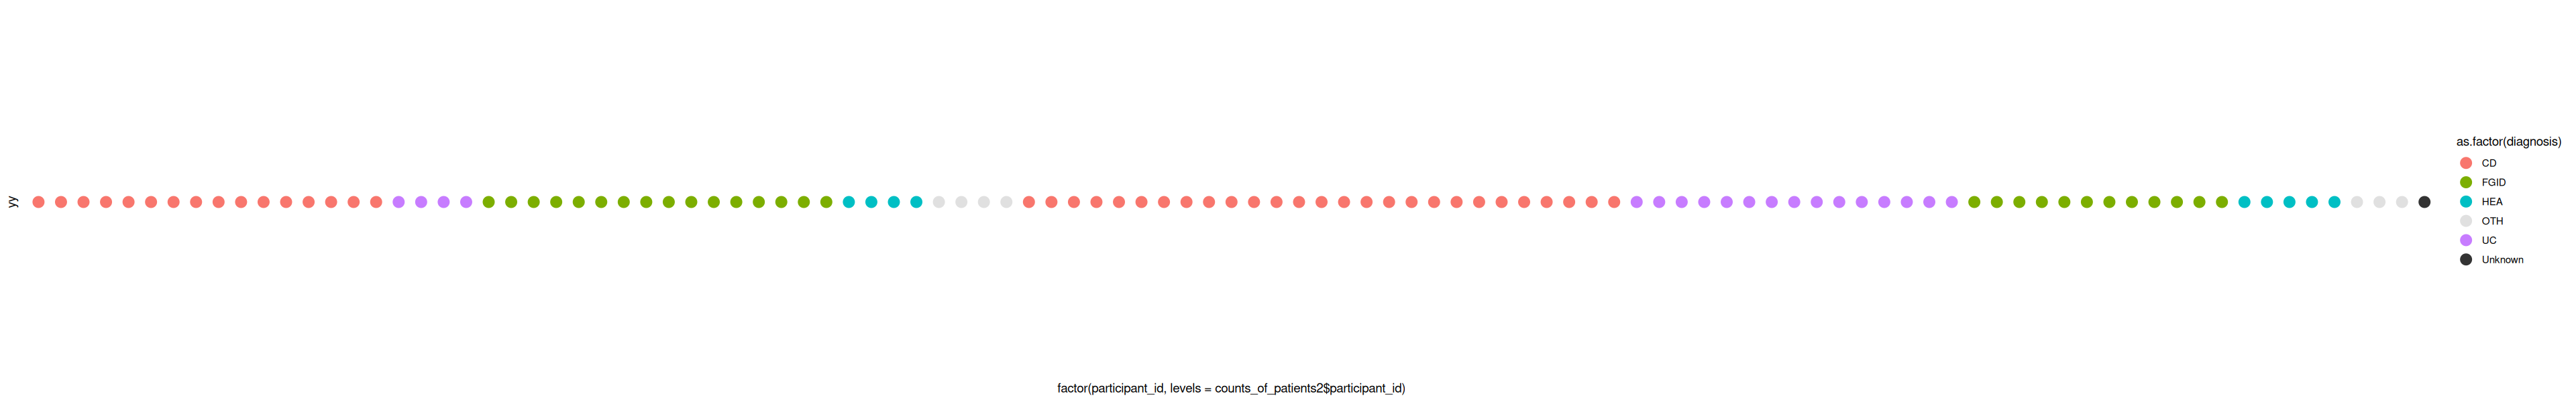

In [173]:
options(repr.plot.width = 32, repr.plot.height = 5)
p

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
W

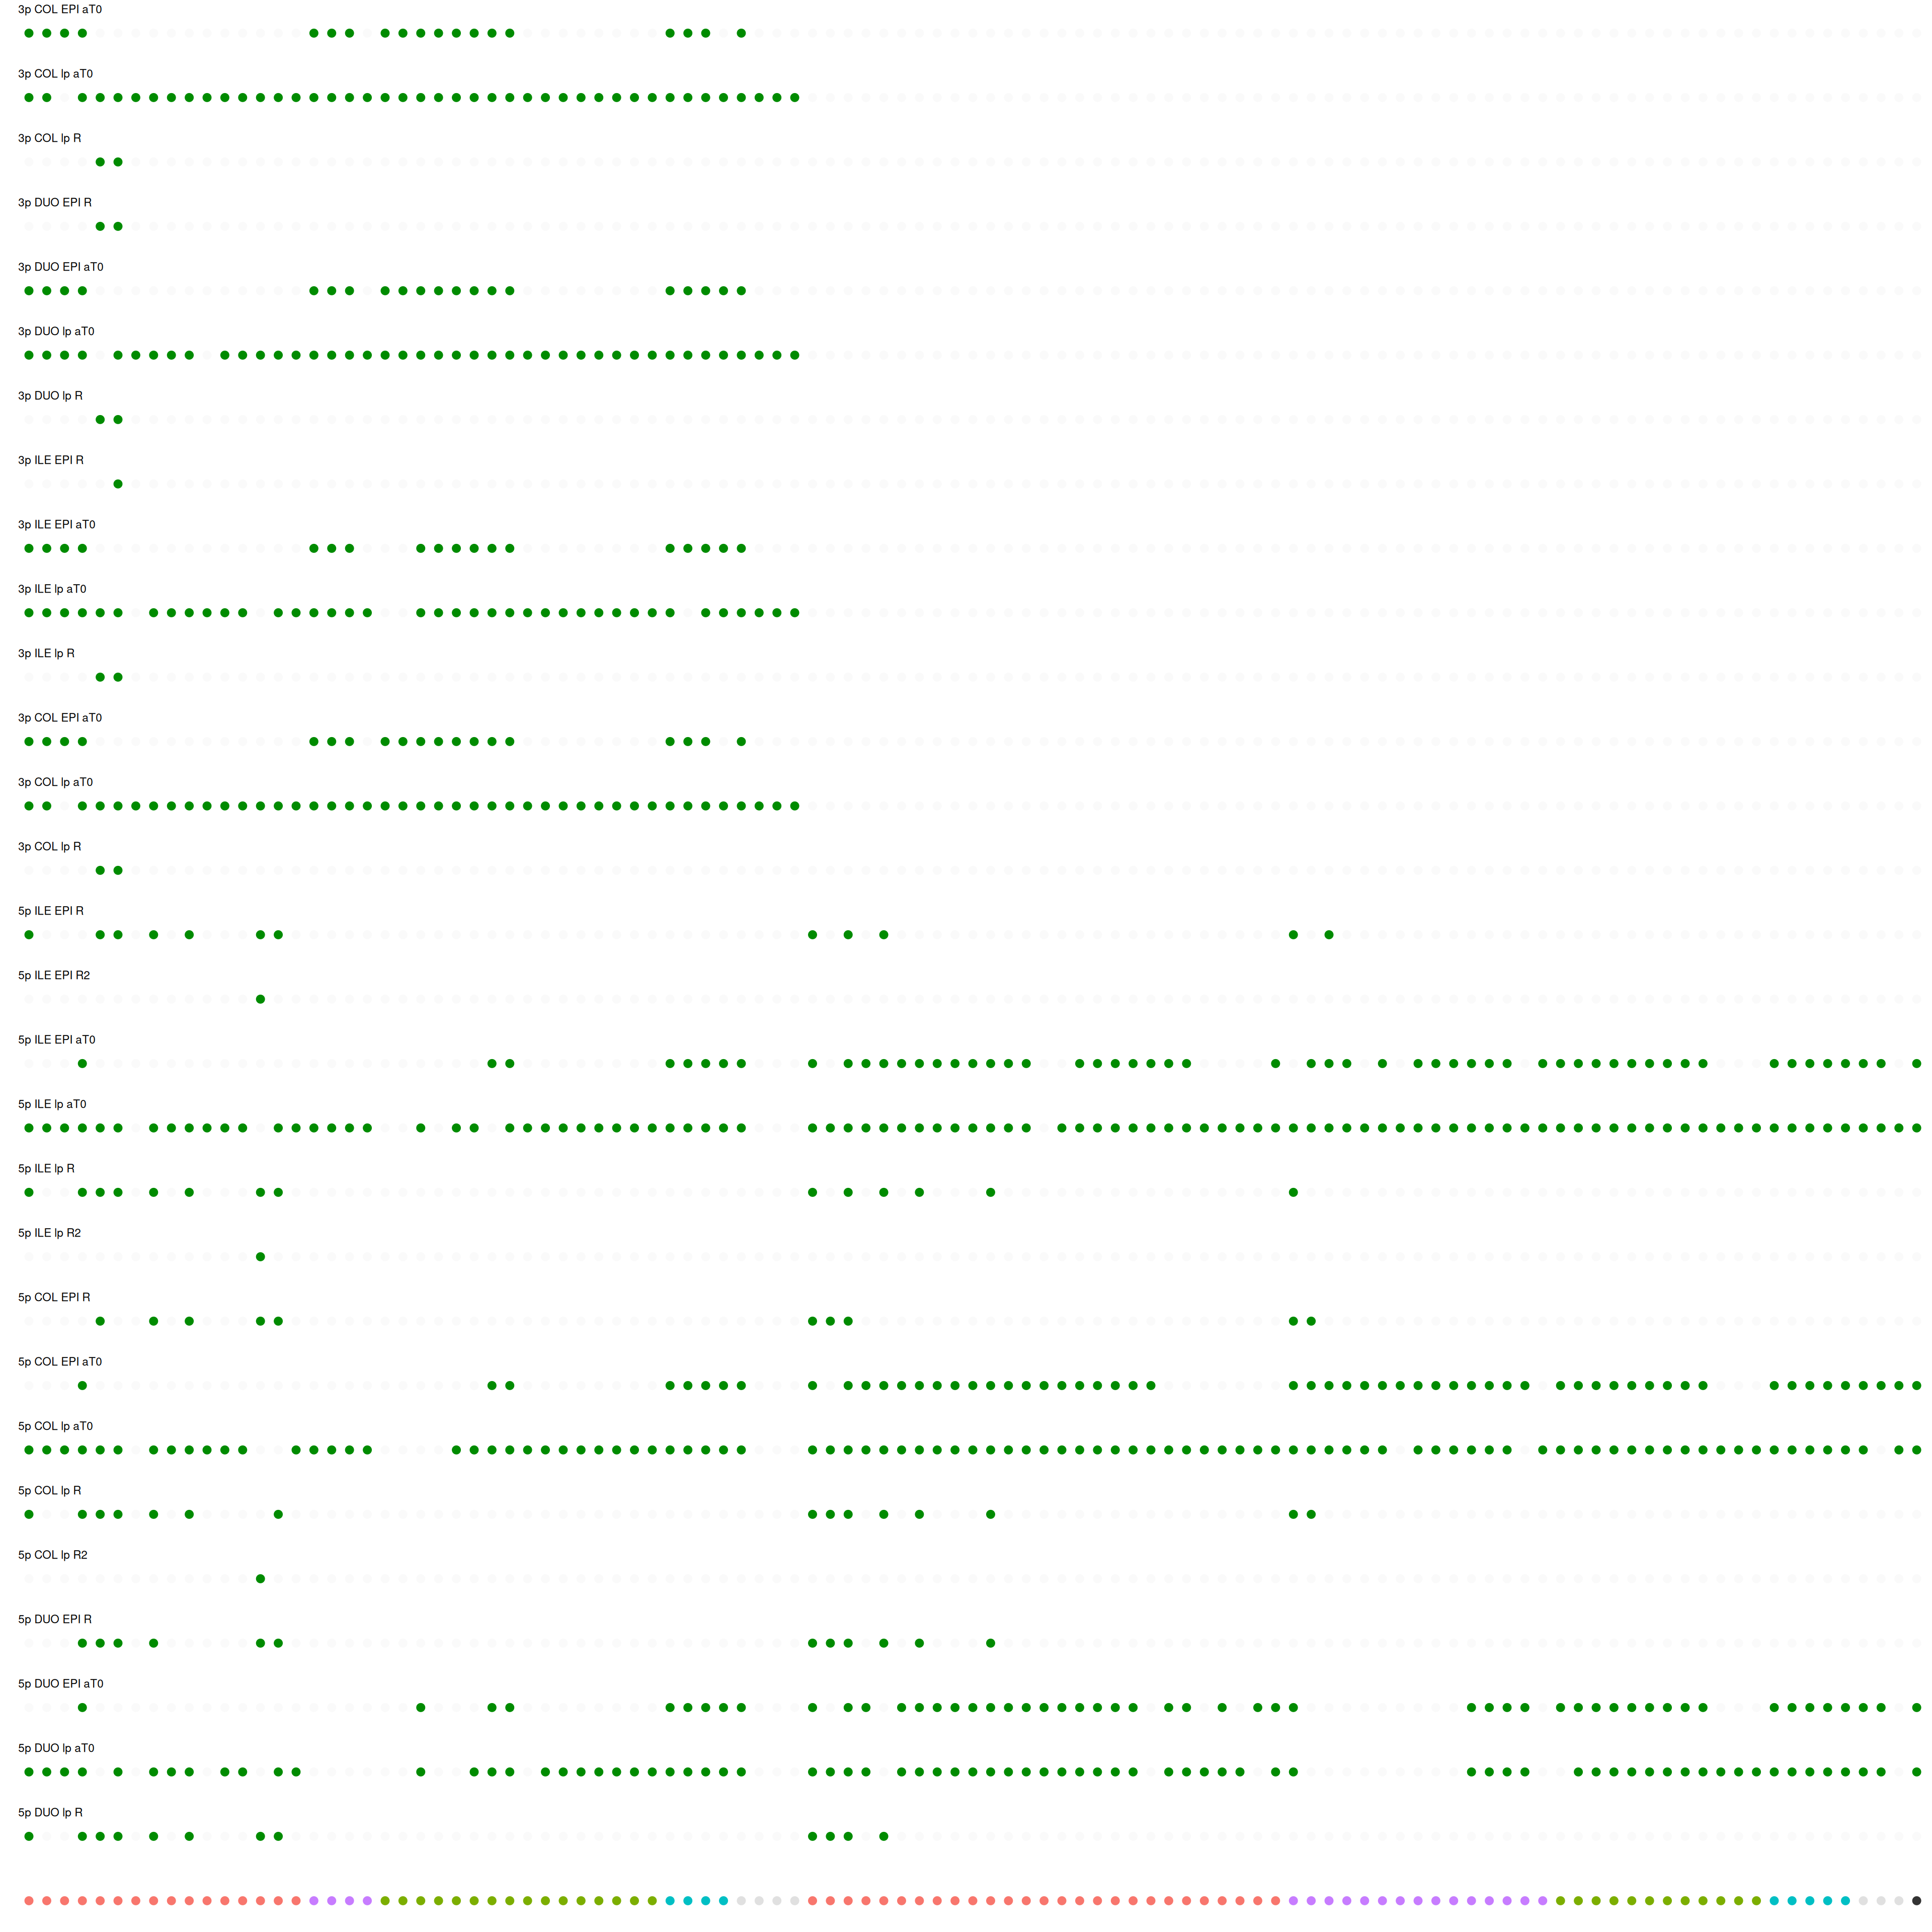

In [214]:
options(repr.plot.width = 32, repr.plot.height = 32)
cowplot::plot_grid(plotlist = plots, ncol = 1)

In [220]:
pdf(file = "figures/cohort_characterization_gut/full_plot.pdf", width = 32, height = 32)
cowplot::plot_grid(plotlist = plots, ncol = 1)
dev.off()

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
W

png 
  2

In [216]:
library(svglite)

combined_plot <- cowplot::plot_grid(plotlist = plots, ncol = 1)

ggsave("figures/cohort_characterization_gut/full_plot.svg", 
       combined_plot, width = 45, height = 45, units = "cm")

Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
Warning message:
“Use of `counts_of_patients2$participant_id` is discouraged.
ℹ Use `participant_id` instead.”
W

In [221]:
patients_3p

[1] "001-002" "001-003" "001-009" "001-010" "001-011" "001-014" "001-015"
 [8] "001-016" "001-017" "001-018" "001-019" "001-020" "001-021" "001-022"
[15] "001-023" "001-024" "001-025" "001-026" "001-027" "001-028" "001-030"
[22] "001-031" "001-032" "001-033" "001-034" "001-035" "001-036" "001-037"
[29] "001-038" "001-040" "001-041" "001-042" "001-043" "001-044" "001-045"
[36] "001-047" "001-048" "001-049" "001-050" "HE-014"  "HE-023"  "HE-024" 
[43] "HE-025"  "HE-026"

In [222]:
patients_5p_only

[1] "001-051" "001-052" "001-053" "001-055" "001-057" "001-058" "001-059"
 [8] "001-062" "001-063" "001-064" "001-066" "001-068" "001-069" "001-070"
[15] "001-071" "001-074" "001-077" "001-078" "001-079" "001-082" "001-085"
[22] "001-086" "001-089" "001-090" "001-091" "001-092" "001-094" "001-101"
[29] "001-103" "003-001" "003-002" "003-004" "003-005" "003-006" "003-007"
[36] "003-008" "003-010" "003-011" "003-012" "003-016" "003-017" "003-026"
[43] "003-027" "003-030" "003-034" "003-036" "003-039" "003-042" "003-043"
[50] "003-046" "003-051" "003-059" "003-066" "003-072" "003-074" "003-077"
[57] "HE-009"  "HE-011"  "HE-012"  "HE-027"  "HE-028"  "003-024" "003-021"

In [223]:
md_5p  %>% dplyr::filter(participant_id %in% patients_5p_only)  %>% 
dplyr::select(participant_id, age, diagnosis)  %>% unique

,participant_id,age,diagnosis
,<chr>,<dbl>,<chr>
AAACCTGCAATCGGTT-1_1193535_1_1_1_1,001-051,15.866170,CD
AAACCTGTCATAAAGG-1_1193541_1_1_1_1,001-052,11.283030,CD
AAACGGGTCATGCATG-1_1193636_1_1_1_1,001-053,9.585527,FGID
AACGTTGAGACGCACA-1_1271026_1_1_1_1,001-055,17.994042,UC
AAACCTGAGGAGTACC-1_1193588_1_1_1_1,001-055,17.218700,UC
AAACCTGCACTGTCGG-1_1193592_1_1_1_1,001-057,7.274619,UC
AAACCTGTCCCATTTA-1_1271029_1_1_1_1,001-058,17.577632,CD
ACCGTAACAAACTGCT-1_1193545_1_1_1_1,001-058,17.002290,CD
CGCCAAGCATGTCTCC-1_1271036_1_1_1_1,001-059,12.422341,UC


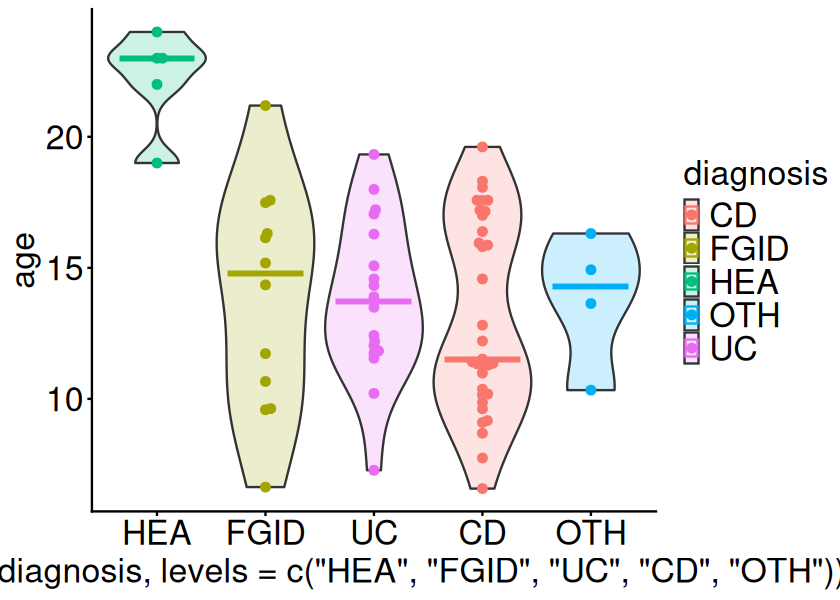

In [57]:
options(repr.plot.width = 7, repr.plot.height = 5)

md_5p  %>% dplyr::filter(participant_id %in% patients_5p_only)  %>% 
mutate(diagnosis = ifelse(diagnosis == 'Unknown',"OTH",diagnosis))  %>% 
dplyr::select(participant_id, age, diagnosis)  %>% unique  %>% 
ggplot(aes(x = factor(diagnosis, levels = c("HEA","FGID","UC","CD","OTH")), y = age)) +
geom_violin(scale = "width", aes(fill = diagnosis), alpha = 0.2) +
stat_summary(fun = "median",
               geom = "crossbar", 
               width = 0.7,
               aes(colour = diagnosis)) +
ggbeeswarm::geom_beeswarm(size = 2, aes(color = diagnosis)) +
theme_classic() +
ggtheme()

ggsave()

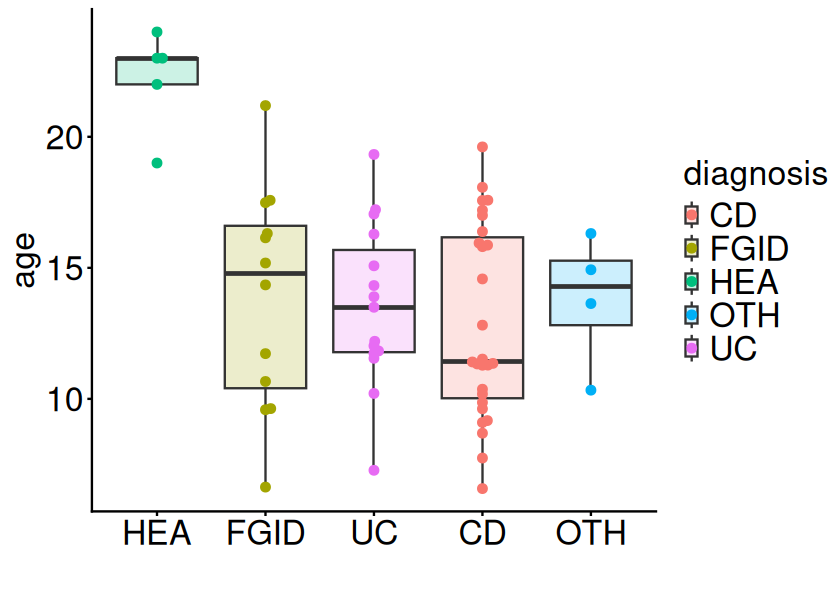

In [69]:
options(repr.plot.width = 7, repr.plot.height = 5)

md_5p  %>% dplyr::filter(participant_id %in% patients_5p_only)  %>% 
dplyr::filter(timepoint == "T0")  %>% 
mutate(diagnosis = ifelse(diagnosis == 'Unknown',"OTH",diagnosis))  %>% 
dplyr::select(participant_id, age, diagnosis)  %>% unique  %>% 
ggplot(aes(x = factor(diagnosis, levels = c("HEA","FGID","UC","CD","OTH")), y = age)) +
geom_boxplot(outlier.shape = NA, aes(fill = diagnosis), alpha = 0.2) +
ggbeeswarm::geom_beeswarm(size = 2, aes(color = diagnosis)) +
theme_classic() +
ggtheme() +
xlab("")

ggsave("figures/cohort_characterization_gut/age_validation.svg", width = 16, height = 10, units = "cm")

Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”


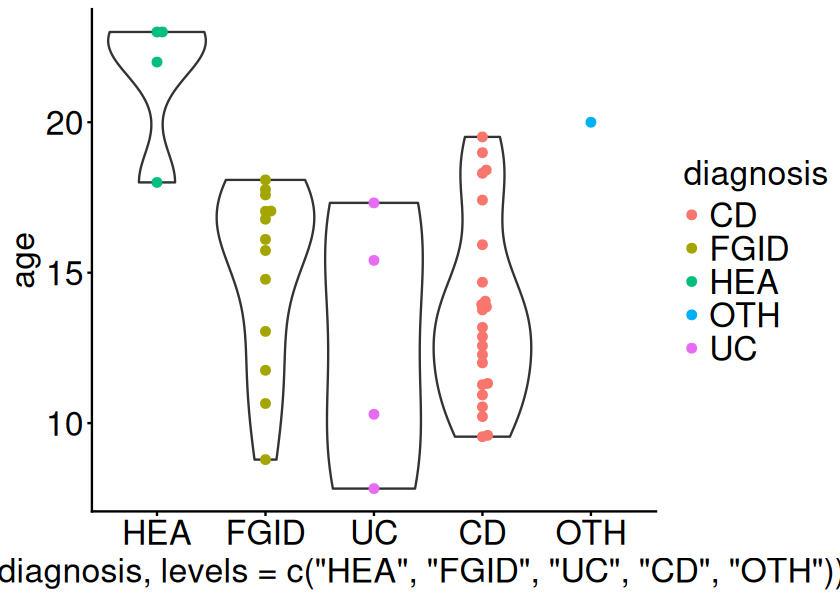

In [47]:
md_5p  %>% dplyr::filter(participant_id %in% patients_3p)  %>% 
mutate(diagnosis = ifelse(diagnosis %in% c("CD","FGID","HEA","UC"),diagnosis,"OTH"))  %>% 
dplyr::select(participant_id, age, diagnosis)  %>% unique  %>% 
ggplot(aes(x = factor(diagnosis, levels = c("HEA","FGID","UC","CD","OTH")), y = age)) +
geom_violin(scale = "width") +
ggbeeswarm::geom_beeswarm(size = 2, aes(color = diagnosis)) +
theme_classic() +
ggtheme()

In [67]:
md_5p$timepoint  %>% table

.
     R     R2     T0 
 66727   2311 519025 

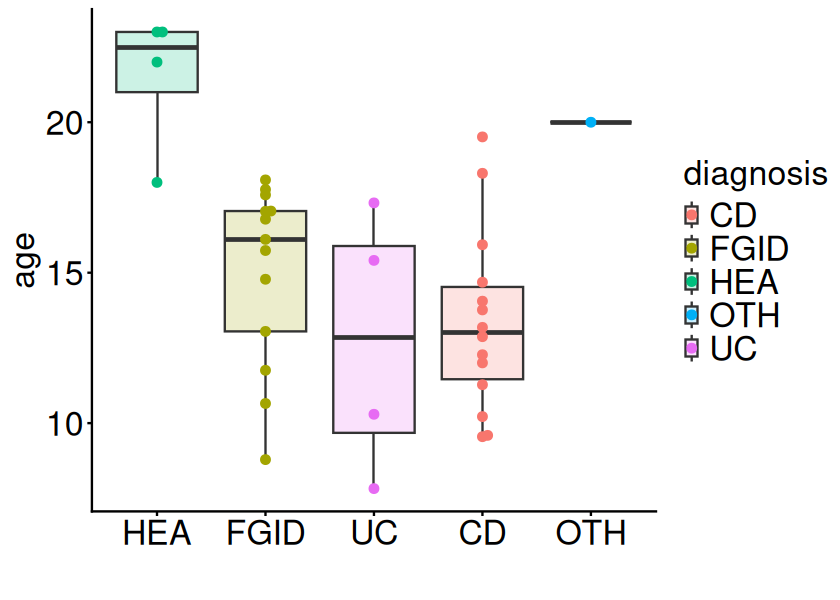

In [68]:
md_5p  %>% dplyr::filter(participant_id %in% patients_3p)  %>% 
dplyr::filter(timepoint == "T0")  %>% 
mutate(diagnosis = ifelse(diagnosis == 'Unknown',"OTH",diagnosis))  %>% 
dplyr::select(participant_id, age, diagnosis)  %>% unique  %>% 
ggplot(aes(x = factor(diagnosis, levels = c("HEA","FGID","UC","CD","OTH")), y = age)) +
geom_boxplot(outlier.shape = NA, aes(fill = diagnosis), alpha = 0.2) +
ggbeeswarm::geom_beeswarm(size = 2, aes(color = diagnosis)) +
theme_classic() +
ggtheme() +
xlab("")

ggsave("figures/cohort_characterization_gut/age_identification.svg", width = 16, height = 10, units = "cm")

In [62]:
md_5p  %>% dplyr::filter(participant_id %in% patients_3p)  %>% 
mutate(diagnosis = ifelse(diagnosis == 'Unknown',"OTH",diagnosis))  %>% 
dplyr::select(participant_id, sex, diagnosis)  %>% unique  %>% 
group_by(sex, diagnosis)  %>%
tally()

sex,diagnosis,n
<chr>,<chr>,<int>
F,CD,7
F,FGID,5
F,HEA,2
F,OTH,1
F,UC,1
M,CD,8
M,FGID,8
M,HEA,2
M,UC,3


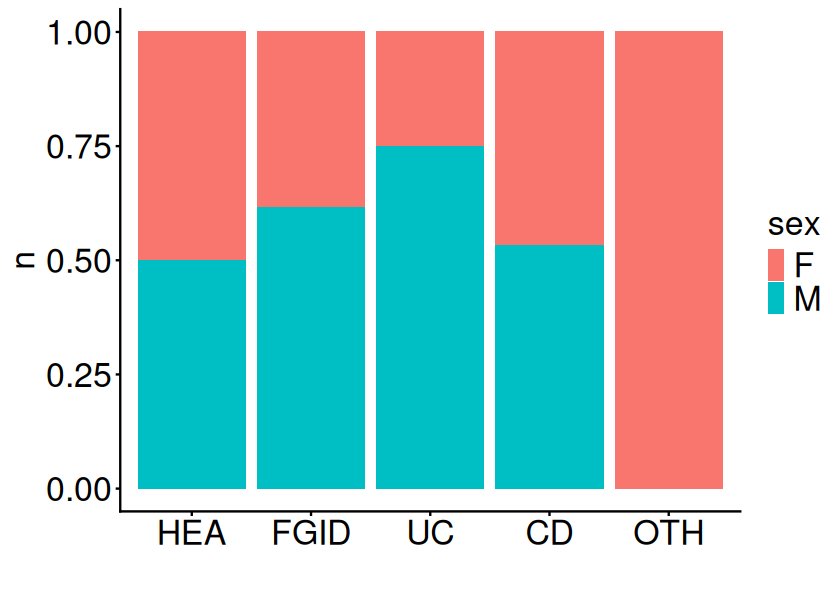

In [64]:
md_5p  %>% dplyr::filter(participant_id %in% patients_3p)  %>% 
mutate(diagnosis = ifelse(diagnosis == 'Unknown',"OTH",diagnosis))  %>% 
dplyr::select(participant_id, sex, diagnosis)  %>% unique  %>% 
group_by(sex, diagnosis)  %>%
tally()  %>% 
ggplot(aes(x = factor(diagnosis, levels = c("HEA","FGID","UC","CD","OTH")), y = n, fill = sex)) +
  geom_bar(position="fill", stat="identity") +
theme_classic() +
ggtheme() +
xlab("")

ggsave("figures/cohort_characterization_gut/sex_identification.svg", width = 16, height = 10, units = "cm")

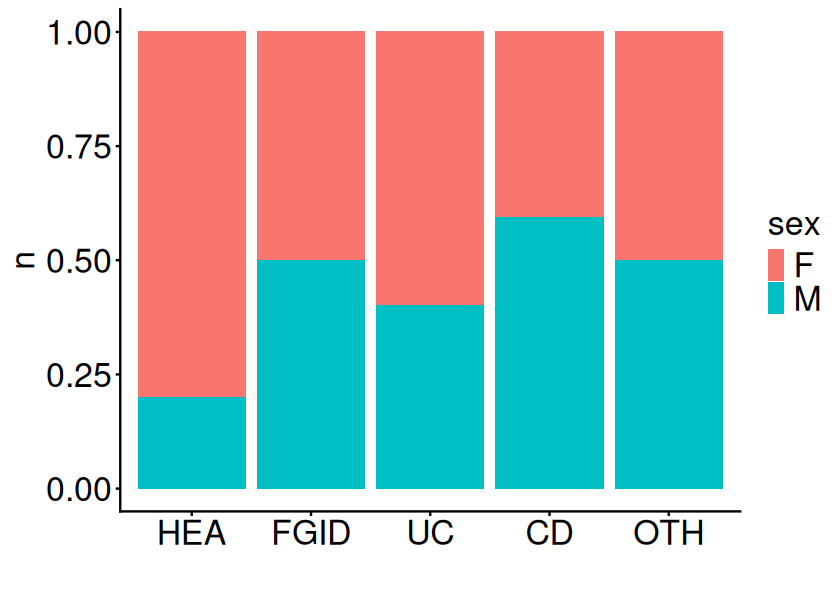

In [65]:
md_5p  %>% dplyr::filter(participant_id %in% patients_5p_only)  %>% 
mutate(diagnosis = ifelse(diagnosis == 'Unknown',"OTH",diagnosis))  %>% 
dplyr::select(participant_id, sex, diagnosis)  %>% unique  %>% 
group_by(sex, diagnosis)  %>%
tally()  %>% 
ggplot(aes(x = factor(diagnosis, levels = c("HEA","FGID","UC","CD","OTH")), y = n, fill = sex)) +
  geom_bar(position="fill", stat="identity") +
theme_classic() +
ggtheme() +
xlab("")

ggsave("figures/cohort_characterization_gut/sex_validation.svg", width = 16, height = 10, units = "cm")

In [66]:
colnames(md_5p)

[1] "...1"                        "orig.ident"                 
  [3] "nCount_RNA"                  "nFeature_RNA"               
  [5] "bc"                          "data_folder"                
  [7] "data_folder2"                "sample"                     
  [9] "diagnosis"                   "subgroup_primary"           
 [11] "subgroup_secondary"          "subgroup_tertiary"          
 [13] "Rome_coarse"                 "Rome_classification"        
 [15] "antitnf_response"            "participant_id"             
 [17] "timepoint"                   "age"                        
 [19] "sex"                         "site"                       
 [21] "tissue"                      "layer"                      
 [23] "prime"                       "version_10x"                
 [25] "sample_old"                  "data_type"                  
 [27] "seq_run"                     "collection_purpose"         
 [29] "collection_date"             "days"                       
 [31] "antitnf"                     "antitnf_repeat"             
 [33] "duo_inflammation"            "ile_inflammation"           
 [35] "col_inflammation"            "sample_inflamed"            
 [37] "colon_site"                  "score_type"                 
 [39] "severity_score"              "weighted_severity_score"    
 [41] "severity_score_date"         "severity_score_range"       
 [43] "weighted_score_range"        "barcodes"                   
 [45] "scrublet_doublet_scores"     "outliers"                   
 [47] "n_outliers"                  "n_genes_by_counts"          
 [49] "log1p_n_genes_by_counts"     "total_counts"               
 [51] "log1p_total_counts"          "pct_counts_in_top_50_genes" 
 [53] "pct_counts_in_top_100_genes" "pct_counts_in_top_200_genes"
 [55] "pct_counts_in_top_500_genes" "total_counts_mt"            
 [57] "log1p_total_counts_mt"       "pct_counts_mt"              
 [59] "total_counts_ribo"           "log1p_total_counts_ribo"    
 [61] "pct_counts_ribo"             "total_counts_hb"            
 [63] "log1p_total_counts_hb"       "pct_counts_hb"              
 [65] "quality_label"               "predicted_labels"           
 [67] "celltypist_score"            "lvl1_annot"                 
 [69] "quality_label1"              "quality_label2"             
 [71] "quality_label3"              "lvl2_annot"                 
 [73] "leiden_0.05"                 "leiden_0.1"                 
 [75] "leiden_0.125"                "leiden_0.15"                
 [77] "leiden_0.175"                "leiden_0.2"                 
 [79] "leiden_0.225"                "leiden_0.25"                
 [81] "leiden_0.3"                  "lvl3_annot_types"           
 [83] "lvl3_annot_states"           "RNA_snn_res.0.3"            
 [85] "seurat_clusters"             "barcode"                    
 [87] "integrated_snn_res.0.5"      "nCount_RNA3"                
 [89] "nFeature_RNA3"               "leiden_0.3_mod"             
 [91] "integrated_snn_res.0.6"      "integrated_snn_res.0.7"     
 [93] "integrated_snn_res.0.8"      "cluster_and_sample"         
 [95] "Singler_Th17"                "age_group"                  
 [97] "is_cell"                     "chain"                      
 [99] "contig_id"                   "high_confidence"            
[101] "productive"                  "length"                     
[103] "reads"                       "umis"                       
[105] "vdj_source"                  "count_TRA"                  
[107] "count_TRB"                   "count_Multi"                
[109] "cdr3_A1"                     "cdr3_A1_nt"                 
[111] "cdr3_A2"                     "cdr3_A2_nt"                 
[113] "cdr3_B"                      "cdr3_B_nt"                  
[115] "cdr3_Multi"                  "cdr3_Multi_nt"              
[117] "v_gene_A1"                   "j_gene_A1"                  
[119] "v_gene_A2"                   "j_gene_A2"                  
[121] "v_gene_B"                    "d_gen

# Data from blood

In [50]:
md_3p_bld  <- read_csv("../241201_VN_PREDICT2/data/metadata/250113_Blood_3p_metadata.csv")
md_5p_bld  <- read_csv("../241201_VN_PREDICT2/data/metadata/250113_Blood_5p_metadata.csv")

New names:
• `` -> `...1`
Rows: 324539 Columns: 20
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (12): ...1, SingleR_HPCA, patient, time, tissue, layer, prime, barcode, ...
dbl  (8): nCount_RNA, nFeature_RNA, RNA_snn_res.0.3, seurat_clusters, percen...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 593574 Columns: 91
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (62): ...1, orig.ident, SingleR_HPCA, data_folder, barcode, sample, diag...
dbl (21): nCount_RNA, nFeature_RNA, percent.mt, percent.rt, RNA_snn_res.0.3,...
lgl  (8): cd4_ctl, is_cell, count_Multi, cdr3_Multi, cdr3_Multi_nt, v_gene_M...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this messa

In [51]:
md_5p_bld$participant_id  %>% table

.
001-009 001-011 001-014 001-015 001-018 001-019 001-022 001-023 001-024 001-026 
   6939    9269    4716    7855   14411   14301   13902   10179   10149    7595 
001-027 001-028 001-030 001-031 001-032 001-033 001-034 001-035 001-040 001-041 
   8397    8107    7780    6587   13060    6867    8281    6399    5963    5738 
001-042 001-043 001-044 001-045 001-047 001-048 001-049 001-050 001-051 001-052 
  10722    7445    6293    8860    8131   16584    7971    8170    9390    8258 
001-053 001-055 001-057 001-058 001-059 001-062 001-063 001-064 001-070 001-071 
   8172    6951    4561   11642   10890   10330    2248   10422    5855    6322 
001-074 001-077 001-078 001-079 001-082 001-086 001-089 001-090 001-091 001-092 
   5899    6343    7037    5466    6542   12066    4884    6603    5812    5386 
001-094 001-101 003-001 003-002 003-004 003-005 003-006 003-007 003-008 003-010 
   6265    6074    4611    6742    3782    2853    8989   11776    4338    3343 
003-011 003-012 003-016 00

### Unify response

In [52]:
md_5p_bld$antitnf_response  %>% table

.
    FR     NM    NOA     NR     PR 
141717 169686 139057  24497 107747 

In [53]:
md_3p_bld$antiTNF_response  %>% table

.
    NM    NOA     PR   RESP 
145995  61989  68453  48102 

### Unify diagnosis

In [54]:
md_5p_bld$diagnosis  %>% table

.
    CD   FGID    HEA    OTH     UC 
296021 146504  19527  16005 104647 

In [55]:
md_3p_bld$disease  %>% table

.
      CD     FGID H Pylori Perineal    Psych       UC 
  146595   120580     7154     8148    10113    31949 

### Unify patient ID

In [56]:
md_3p_bld$patient  %>% table

.
 p002  p003  p009  p010  p011  p014  p015  p016  p017  p018  p019  p020  p021 
 8569  5780  9222   247  7044 11184 10122 17375  6823 14341 16474  8148 10113 
 p022  p023  p024  p025  p026  p027  p028  p030  p031  p032  p033  p034  p035 
 1828  9552  8806  7154  8573  8311  7575  8011  7436  8577  8288  1289   805 
 p036  p037  p038  p040  p041  p042  p043  p044  p045  p047  p048  p049  p050 
 9470  8390  5694  8565  8124 10671  7487 10977 10599  6663  9039  9223  7990 

In [57]:
md_5p_bld$participant_id  %>% table

.
001-009 001-011 001-014 001-015 001-018 001-019 001-022 001-023 001-024 001-026 
   6939    9269    4716    7855   14411   14301   13902   10179   10149    7595 
001-027 001-028 001-030 001-031 001-032 001-033 001-034 001-035 001-040 001-041 
   8397    8107    7780    6587   13060    6867    8281    6399    5963    5738 
001-042 001-043 001-044 001-045 001-047 001-048 001-049 001-050 001-051 001-052 
  10722    7445    6293    8860    8131   16584    7971    8170    9390    8258 
001-053 001-055 001-057 001-058 001-059 001-062 001-063 001-064 001-070 001-071 
   8172    6951    4561   11642   10890   10330    2248   10422    5855    6322 
001-074 001-077 001-078 001-079 001-082 001-086 001-089 001-090 001-091 001-092 
   5899    6343    7037    5466    6542   12066    4884    6603    5812    5386 
001-094 001-101 003-001 003-002 003-004 003-005 003-006 003-007 003-008 003-010 
   6265    6074    4611    6742    3782    2853    8989   11776    4338    3343 
003-011 003-012 003-016 00

### Unify time

In [58]:
md_3p_bld$time  %>% table

.
   T0D    T3M 
301084  23455 

In [59]:
md_5p_bld$timepoint  %>% table

.
     R     R2     T0 
 91012   1421 501141 

In [60]:
md_5p_bld$timepoint  %>% table

.
     R     R2     T0 
 91012   1421 501141 

In [61]:
md_5p_bld$version_10x  <- paste0("5p_", md_5p_bld$version_10x)

In [62]:
colnames(md_3p_bld)

[1] "...1"             "SingleR_HPCA"     "nCount_RNA"       "nFeature_RNA"    
 [5] "patient"          "time"             "tissue"           "layer"           
 [9] "prime"            "RNA_snn_res.0.3"  "seurat_clusters"  "barcode"         
[13] "disease"          "antiTNF_response" "percent.mt"       "percent.rp"      
[17] "RNA_snn_res.0.8"  "manual_annots"    "RNA_snn_res.1"    "smp_id"

In [63]:
head(md_3p_bld)

...1,SingleR_HPCA,nCount_RNA,nFeature_RNA,patient,time,tissue,layer,prime,RNA_snn_res.0.3,seurat_clusters,barcode,disease,antiTNF_response,percent.mt,percent.rp,RNA_snn_res.0.8,manual_annots,RNA_snn_res.1,smp_id
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
Cell1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,T_cells,3308,927,p002,T0D,BLD,CD3,3p,0,4,Cell1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,FGID,NM,2.750907,49.60701,4,00_CD4_Naive,4,p002 T0D BLD CD3
Cell2_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,T_cells,8581,1744,p002,T0D,BLD,CD3,3p,1,3,Cell2_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,FGID,NM,4.102086,51.17119,7,07_CD8,3,p002 T0D BLD CD3
Cell3_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,T_cells,2072,888,p002,T0D,BLD,CD3,3p,2,10,Cell3_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,FGID,NM,3.861004,34.16988,5,05_CD8,10,p002 T0D BLD CD3
Cell4_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,T_cells,3772,892,p002,T0D,BLD,CD3,3p,3,0,Cell4_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,FGID,NM,4.135737,53.41994,1,01_CD8_Naive,0,p002 T0D BLD CD3
Cell5_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,T_cells,2903,840,p002,T0D,BLD,CD3,3p,3,0,Cell5_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,FGID,NM,3.720289,49.12160,1,01_CD8_Naive,0,p002 T0D BLD CD3
Cell6_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,T_cells,8469,2186,p002,T0D,BLD,CD3,3p,6,20,Cell6_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,FGID,NM,5.065533,34.32519,13,13_,20,p002 T0D BLD CD3


In [64]:
md_3p_bld <- md_3p_bld  %>% mutate(diagnosis = ifelse(disease %in% c("CD","FGID","UC"), disease, "OTH"),
                                             antitnf_response = ifelse(antiTNF_response == "RESP", "FR", antiTNF_response),
                                            participant_id = paste0("001-",substr(patient,2,4)),
                                            timepoint= ifelse(time == "T0D", "T0","R"),
                                            version_10x = "3p_v1")

In [65]:
colnames(md_3p_bld) %in% colnames(md_5p_bld)

[1]  TRUE  TRUE  TRUE  TRUE FALSE FALSE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
[13] FALSE FALSE  TRUE FALSE FALSE FALSE FALSE FALSE  TRUE  TRUE  TRUE  TRUE
[25]  TRUE

In [66]:
md_3p_bld_to_join  <- md_3p_bld[,colnames(md_3p_bld) %in% colnames(md_5p_bld)]

In [67]:
md_5p_bld_to_join  <- md_5p_bld[,colnames(md_5p_bld) %in% colnames(md_3p_bld_to_join)]

In [68]:
colnames(md_3p_bld_to_join)

[1] "...1"             "SingleR_HPCA"     "nCount_RNA"       "nFeature_RNA"    
 [5] "tissue"           "layer"            "prime"            "RNA_snn_res.0.3" 
 [9] "seurat_clusters"  "barcode"          "percent.mt"       "diagnosis"       
[13] "antitnf_response" "participant_id"   "timepoint"        "version_10x"

In [69]:
colnames(md_3p_bld_to_join)[order(colnames(md_3p_bld_to_join))]

[1] "...1"             "antitnf_response" "barcode"          "diagnosis"       
 [5] "layer"            "nCount_RNA"       "nFeature_RNA"     "participant_id"  
 [9] "percent.mt"       "prime"            "RNA_snn_res.0.3"  "seurat_clusters" 
[13] "SingleR_HPCA"     "timepoint"        "tissue"           "version_10x"

In [70]:
colnames(md_5p_bld_to_join)[order(colnames(md_5p_bld_to_join))]

[1] "...1"             "antitnf_response" "barcode"          "diagnosis"       
 [5] "layer"            "nCount_RNA"       "nFeature_RNA"     "participant_id"  
 [9] "percent.mt"       "prime"            "RNA_snn_res.0.3"  "seurat_clusters" 
[13] "SingleR_HPCA"     "timepoint"        "tissue"           "version_10x"

In [71]:
md_3p_bld_to_join  <- md_3p_bld_to_join[,order(colnames(md_3p_bld_to_join))]
md_5p_bld_to_join  <- md_5p_bld_to_join[,order(colnames(md_5p_bld_to_join))]
colnames(md_3p_bld_to_join) == colnames(md_5p_bld_to_join)

[1] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
[16] TRUE

In [72]:
md_3p_bld_to_join$dataset  <- "2021"
md_5p_bld_to_join$dataset  <- "2024"

In [73]:
md_5p_bld_to_join$participant_id  %>% table

.
001-009 001-011 001-014 001-015 001-018 001-019 001-022 001-023 001-024 001-026 
   6939    9269    4716    7855   14411   14301   13902   10179   10149    7595 
001-027 001-028 001-030 001-031 001-032 001-033 001-034 001-035 001-040 001-041 
   8397    8107    7780    6587   13060    6867    8281    6399    5963    5738 
001-042 001-043 001-044 001-045 001-047 001-048 001-049 001-050 001-051 001-052 
  10722    7445    6293    8860    8131   16584    7971    8170    9390    8258 
001-053 001-055 001-057 001-058 001-059 001-062 001-063 001-064 001-070 001-071 
   8172    6951    4561   11642   10890   10330    2248   10422    5855    6322 
001-074 001-077 001-078 001-079 001-082 001-086 001-089 001-090 001-091 001-092 
   5899    6343    7037    5466    6542   12066    4884    6603    5812    5386 
001-094 001-101 003-001 003-002 003-004 003-005 003-006 003-007 003-008 003-010 
   6265    6074    4611    6742    3782    2853    8989   11776    4338    3343 
003-011 003-012 003-016 00

In [74]:
md_3p_bld_to_join$dataset  <- "2021"
md_5p_bld_to_join$dataset  <- "2024"

md  <- rbind(md_3p_bld_to_join, md_5p_bld_to_join)


counts_of_patients <- md  %>% 
group_by(participant_id, dataset, timepoint)  %>% tally  %>% ungroup  %>% 
dplyr::select(-n)  %>% group_by(participant_id, dataset, timepoint)  %>% tally  %>% 
mutate(dataset_time = paste(dataset, timepoint))  %>% ungroup  %>% 
dplyr::select(-dataset, -timepoint)  %>% 
pivot_wider(names_from = dataset_time, values_from = n, values_fill = 0)  %>% 
mutate(yy = 1)

In [75]:
counts_of_patients

participant_id,2021 T0,2024 T0,2024 R,2021 R,2024 R2,yy
<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>
001-002,1,0,0,0,0,1
001-003,1,0,0,0,0,1
001-009,1,1,0,0,0,1
001-010,1,0,0,0,0,1
001-011,1,1,1,0,0,1
001-014,1,0,1,1,0,1
001-015,1,1,0,0,0,1
001-016,1,0,0,1,0,1
001-017,1,0,0,0,0,1


In [43]:
counts_of_patients

participant_id,3p COL EPI aT0,3p COL LP R,3p COL LP aT0,3p DUO EPI R,3p DUO EPI aT0,3p DUO LP R,3p DUO LP aT0,3p ILE EPI R,3p ILE EPI aT0,⋯,5p DUO EPI aT0,5p DUO LP R,5p DUO LP aT0,5p ILE EPI R,5p ILE EPI R2,5p ILE EPI aT0,5p ILE LP R,5p ILE LP R2,5p ILE LP aT0,yy
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>
001-002,1,0,1,0,1,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,1
001-003,1,0,1,0,1,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,1
001-015,1,0,1,0,1,0,1,0,1,⋯,0,0,0,0,0,0,0,0,1,1
001-018,1,0,1,0,1,0,1,0,1,⋯,0,1,1,1,0,0,1,0,1,1
001-024,1,0,1,0,1,0,1,0,1,⋯,0,0,1,0,0,0,0,0,1,1
001-031,1,0,0,0,1,0,1,0,1,⋯,0,0,1,0,0,0,0,0,1,1
001-035,1,0,1,0,1,0,1,0,1,⋯,1,0,1,0,0,0,0,0,1,1
001-036,1,0,1,0,1,0,1,0,1,⋯,0,0,0,0,0,0,0,0,1,1
001-037,1,0,1,0,1,0,1,0,1,⋯,0,0,0,0,0,0,0,0,0,1


In [44]:
counts_of_patients2

participant_id,3p COL EPI aT0,3p COL LP R,3p COL LP aT0,3p DUO EPI R,3p DUO EPI aT0,3p DUO LP R,3p DUO LP aT0,3p ILE EPI R,3p ILE EPI aT0,⋯,5p ILE EPI R,5p ILE EPI R2,5p ILE EPI aT0,5p ILE LP R,5p ILE LP R2,5p ILE LP aT0,yy,diagnosis,diagnosis2,order
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<chr>,<fct>,<chr>
001-018,1,0,1,0,1,0,1,0,1,⋯,1,0,0,1,0,1,1,CD,01_CD,0
001-024,1,0,1,0,1,0,1,0,1,⋯,0,0,0,0,0,1,1,CD,01_CD,0
001-031,1,0,0,0,1,0,1,0,1,⋯,0,0,0,0,0,1,1,CD,01_CD,0
001-048,1,0,1,0,1,0,1,0,1,⋯,0,0,1,1,0,1,1,CD,01_CD,0
001-014,0,1,1,1,0,1,0,0,0,⋯,1,0,0,1,0,1,1,CD,01_CD,0
001-019,0,1,1,1,0,1,1,1,0,⋯,1,0,0,1,0,1,1,CD,01_CD,0
001-010,0,0,1,0,0,0,1,0,0,⋯,0,0,0,0,0,0,1,CD,01_CD,0
001-011,0,0,1,0,0,0,1,0,0,⋯,1,0,0,1,0,1,1,CD,01_CD,0
001-016,0,0,1,0,0,0,1,0,0,⋯,0,0,0,0,0,1,1,CD,01_CD,0


In [45]:
counts_of_patients$participant_id %in% counts_of_patients2$participant_id  %>% table

.
TRUE 
 107 

In [46]:
counts_of_patients3  <- left_join(counts_of_patients2, counts_of_patients)

Joining with `by = join_by(participant_id, `3p COL EPI aT0`, `3p COL LP R`, `3p
COL LP aT0`, `3p DUO EPI R`, `3p DUO EPI aT0`, `3p DUO LP R`, `3p DUO LP aT0`,
`3p ILE EPI R`, `3p ILE EPI aT0`, `3p ILE LP R`, `3p ILE LP aT0`, `5p COL EPI
R`, `5p COL EPI aT0`, `5p COL LP R`, `5p COL LP R2`, `5p COL LP aT0`, `5p DUO
EPI R`, `5p DUO EPI aT0`, `5p DUO LP R`, `5p DUO LP aT0`, `5p ILE EPI R`, `5p
ILE EPI R2`, `5p ILE EPI aT0`, `5p ILE LP R`, `5p ILE LP R2`, `5p ILE LP aT0`,
yy)`


In [47]:
counts_of_patients3

participant_id,3p COL EPI aT0,3p COL LP R,3p COL LP aT0,3p DUO EPI R,3p DUO EPI aT0,3p DUO LP R,3p DUO LP aT0,3p ILE EPI R,3p ILE EPI aT0,⋯,5p ILE EPI R,5p ILE EPI R2,5p ILE EPI aT0,5p ILE LP R,5p ILE LP R2,5p ILE LP aT0,yy,diagnosis,diagnosis2,order
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<chr>,<fct>,<chr>
001-018,1,0,1,0,1,0,1,0,1,⋯,1,0,0,1,0,1,1,CD,01_CD,0
001-024,1,0,1,0,1,0,1,0,1,⋯,0,0,0,0,0,1,1,CD,01_CD,0
001-031,1,0,0,0,1,0,1,0,1,⋯,0,0,0,0,0,1,1,CD,01_CD,0
001-048,1,0,1,0,1,0,1,0,1,⋯,0,0,1,1,0,1,1,CD,01_CD,0
001-014,0,1,1,1,0,1,0,0,0,⋯,1,0,0,1,0,1,1,CD,01_CD,0
001-019,0,1,1,1,0,1,1,1,0,⋯,1,0,0,1,0,1,1,CD,01_CD,0
001-010,0,0,1,0,0,0,1,0,0,⋯,0,0,0,0,0,0,1,CD,01_CD,0
001-011,0,0,1,0,0,0,1,0,0,⋯,1,0,0,1,0,1,1,CD,01_CD,0
001-016,0,0,1,0,0,0,1,0,0,⋯,0,0,0,0,0,1,1,CD,01_CD,0


## Add age, sex, diagnosis, response

In [40]:
md_predict  <- read_csv("../241201_VN_PREDICT2/data/metadata/predict_5p_metadata_20241015.csv")

Rows: 1229 Columns: 38
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (36): sample, data_folder, diagnosis, subgroup_primary, subgroup_seconda...
dbl  (2): age, days

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [41]:
colnames(md_predict)

[1] "sample"                  "data_folder"            
 [3] "diagnosis"               "subgroup_primary"       
 [5] "subgroup_secondary"      "subgroup_tertiary"      
 [7] "Rome_coarse"             "Rome_classification"    
 [9] "antitnf_response"        "participant_id"         
[11] "timepoint"               "age"                    
[13] "sex"                     "site"                   
[15] "tissue"                  "layer"                  
[17] "prime"                   "version_10x"            
[19] "sample_old"              "data_type"              
[21] "seq_run"                 "collection_purpose"     
[23] "collection_date"         "days"                   
[25] "antitnf"                 "antitnf_repeat"         
[27] "duo_inflammation"        "ile_inflammation"       
[29] "col_inflammation"        "sample_inflamed"        
[31] "colon_site"              "score_type"             
[33] "severity_score"          "weighted_severity_score"
[35] "severity_score_date"     "severity_score_range"   
[37] "weighted_score_range"    "internal_flag"

In [48]:
table(counts_of_patients3$participant_id %in% md_predict$participant_id)


FALSE  TRUE 
    4   103 

In [49]:
counts_of_patients3$participant_id[which(!counts_of_patients3$participant_id %in% md_predict$participant_id)]

[1] "001-003" "001-020" "001-021" "001-025"

In [50]:
md_predict$timepoint  %>% table

.
   R   R2   T0 
 186   10 1033 

In [54]:
md_predict  %>% 
dplyr::filter(timepoint == "T0")  %>% 
dplyr::select(age,sex,antitnf_response, participant_id, diagnosis)  %>% group_by_all  %>% tally()  %>% arrange(participant_id)

age,sex,antitnf_response,participant_id,diagnosis,n
<dbl>,<chr>,<chr>,<chr>,<chr>,<int>
14.135810,M,NM,001-002,FGID,2
14.365680,F,FR,001-004,CD,2
17.166680,F,NOA,001-006,UC,1
13.048860,M,NM,001-009,FGID,8
10.989960,M,PR,001-010,CD,2
12.002980,M,FR,001-011,CD,7
11.277550,F,FR,001-014,CD,5
10.294640,F,NOA,001-015,UC,6
14.683395,M,FR,001-016,CD,6


In [57]:
md_predict  %>% 
dplyr::filter(timepoint == "T0")  %>% 
dplyr::select(age,sex,antitnf_response, participant_id, diagnosis)  %>% group_by_all  %>% tally()  %>% arrange(participant_id)  %>% 
group_by(diagnosis)  %>% 
summarise(min = min(age), max = max(age), median = median(age))

diagnosis,min,max,median
<chr>,<dbl>,<dbl>,<dbl>
CD,6.576453,19.61448,12.54366
FGID,6.633835,21.19140,15.18443
HEA,18.000000,24.00000,23.00000
OTH,10.332860,20.00000,14.97355
UC,7.274619,19.32700,13.69632
NA,14.927069,14.92707,14.92707


In [52]:
md_to_join  <- md_predict  %>% 
dplyr::filter(timepoint == "T0")  %>% 
dplyr::select(age,sex,antitnf_response, participant_id)  %>% group_by_all  %>% tally()  %>% arrange(participant_id)  %>% 
dplyr::select(-n)

In [53]:
counts_of_patients4  <- left_join(counts_of_patients3, md_to_join)

Joining with `by = join_by(participant_id)`


In [98]:
write.csv(counts_of_patients4, "tables/participant_metadata.csv")